### Hakes and Sauer Table 3 
Salary against OBP and SLG

# Creating the dataframe

We will now set about reproducing Table 3.
<br>
To re-run the Hakes and Sauer Table 3 regression we need to create a df containing the the variables they used:

>log(Salary) = b<sub>0</sub> + b<sub>1</sub> OBP + b<sub>2</sub> SLG + b<sub>3</sub> PA + b<sub>4</sub> Arb + b<sub>5</sub> Free + b<sub>6</sub> Catcher + b<sub>7</sub> Infielder


*The Salary data is in the salary file (Step 1)*

*The OBP, SLG and PA data can be created from the batting file (Step 2)*

*The Arb (arbitration elegible) and Free (agent) data can be created from the People file (Step 3)*

*The Catcher and Infielder can be created from the Appearances file (Step 4)*

We will combine all these variables in a Master file, and then run the regessions.


## Merging dataframes

Before running the code, it's useful to visualize the process. To run the regression at the end, we want to create a "rectangular" dataframe. All our variables will be lined up in columns and the number of rows will be the same for each variable. We will also discard rows where there are missing variables. You can think of the df as looking like this:

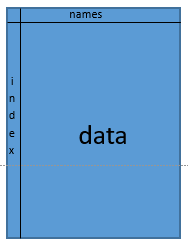

To create our df we need to merge data from different sources. 

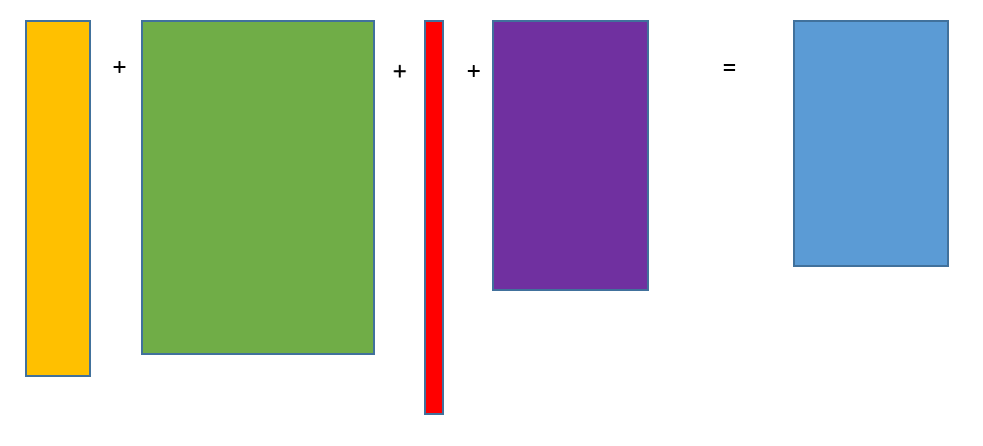

This will involve operations to:
<br>
>Create new variables inside an existing df.
<br>
>Merge two dfs.
<br>
>Drop variables that are not relevant for our final df.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
Salary = pd.read_csv('Salaries.csv')
display(Salary)

,yearID,teamID,lgID,playerID,salary
0,1985,ATL,NL,barkele01,870000
1,1985,ATL,NL,bedrost01,550000
2,1985,ATL,NL,benedbr01,545000
3,1985,ATL,NL,campri01,633333
4,1985,ATL,NL,ceronri01,625000
...,...,...,...,...,...
26423,2016,WAS,NL,strasst01,10400000
26424,2016,WAS,NL,taylomi02,524000
26425,2016,WAS,NL,treinbl01,524900
26426,2016,WAS,NL,werthja01,21733615


In [3]:
Salary = Salary[Salary.salary > 0]
Salary

,yearID,teamID,lgID,playerID,salary
0,1985,ATL,NL,barkele01,870000
1,1985,ATL,NL,bedrost01,550000
2,1985,ATL,NL,benedbr01,545000
3,1985,ATL,NL,campri01,633333
4,1985,ATL,NL,ceronri01,625000
...,...,...,...,...,...
26423,2016,WAS,NL,strasst01,10400000
26424,2016,WAS,NL,taylomi02,524000
26425,2016,WAS,NL,treinbl01,524900
26426,2016,WAS,NL,werthja01,21733615


In [4]:
Salary['lnSal'] = np.log(Salary.loc[:, 'salary'])
Salary

,yearID,teamID,lgID,playerID,salary,lnSal
0,1985,ATL,NL,barkele01,870000,13.676248
1,1985,ATL,NL,bedrost01,550000,13.217674
2,1985,ATL,NL,benedbr01,545000,13.208541
3,1985,ATL,NL,campri01,633333,13.358752
4,1985,ATL,NL,ceronri01,625000,13.345507
...,...,...,...,...,...,...
26423,2016,WAS,NL,strasst01,10400000,16.157316
26424,2016,WAS,NL,taylomi02,524000,13.169247
26425,2016,WAS,NL,treinbl01,524900,13.170963
26426,2016,WAS,NL,werthja01,21733615,16.894371


In [5]:
Salary = Salary.rename(columns = {'yearID':'SalYear'})
Salary

,SalYear,teamID,lgID,playerID,salary,lnSal
0,1985,ATL,NL,barkele01,870000,13.676248
1,1985,ATL,NL,bedrost01,550000,13.217674
2,1985,ATL,NL,benedbr01,545000,13.208541
3,1985,ATL,NL,campri01,633333,13.358752
4,1985,ATL,NL,ceronri01,625000,13.345507
...,...,...,...,...,...,...
26423,2016,WAS,NL,strasst01,10400000,16.157316
26424,2016,WAS,NL,taylomi02,524000,13.169247
26425,2016,WAS,NL,treinbl01,524900,13.170963
26426,2016,WAS,NL,werthja01,21733615,16.894371


In [6]:
Master = Salary
Master

,SalYear,teamID,lgID,playerID,salary,lnSal
0,1985,ATL,NL,barkele01,870000,13.676248
1,1985,ATL,NL,bedrost01,550000,13.217674
2,1985,ATL,NL,benedbr01,545000,13.208541
3,1985,ATL,NL,campri01,633333,13.358752
4,1985,ATL,NL,ceronri01,625000,13.345507
...,...,...,...,...,...,...
26423,2016,WAS,NL,strasst01,10400000,16.157316
26424,2016,WAS,NL,taylomi02,524000,13.169247
26425,2016,WAS,NL,treinbl01,524900,13.170963
26426,2016,WAS,NL,werthja01,21733615,16.894371


# Step 2 

In [7]:
pd.set_option('display.max_columns', 50)

Batting = pd.read_csv('Batting.csv')
display(Batting)

,playerID,yearID,stint,teamID,lgID,G,AB,R,H,Doubles,Triples,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,abercda01,1871,1,TRO,NaN,1,4,0,0,0,0,0,0.0,0.0,0.0,0,0.0,NaN,NaN,NaN,NaN,NaN
1,addybo01,1871,1,RC1,NaN,25,118,30,32,6,0,0,13.0,8.0,1.0,4,0.0,NaN,NaN,NaN,NaN,NaN
2,allisar01,1871,1,CL1,NaN,29,137,28,40,4,5,0,19.0,3.0,1.0,2,5.0,NaN,NaN,NaN,NaN,NaN
3,allisdo01,1871,1,WS3,NaN,27,133,28,44,10,2,2,27.0,1.0,1.0,0,2.0,NaN,NaN,NaN,NaN,NaN
4,ansonca01,1871,1,RC1,NaN,25,120,29,39,11,3,0,16.0,6.0,2.0,2,1.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102811,zimmejo02,2016,1,DET,AL,19,4,0,1,0,0,0,0.0,0.0,0.0,0,2.0,0.0,0.0,1.0,0.0,0.0
102812,zimmery01,2016,1,WAS,NL,115,427,60,93,18,1,15,46.0,4.0,1.0,29,104.0,1.0,5.0,0.0,6.0,12.0
102813,zobribe01,2016,1,CHN,NL,147,523,94,142,31,3,18,76.0,6.0,4.0,96,82.0,6.0,4.0,4.0,4.0,17.0
102814,zuninmi01,2016,1,SEA,AL,55,164,16,34,7,0,12,31.0,0.0,0.0,21,65.0,0.0,6.0,0.0,1.0,0.0


## Stints

In [8]:
Batting = Batting.groupby(['playerID', 'yearID']).sum()
Batting.reset_index(inplace=True)
Batting

,playerID,yearID,stint,G,AB,R,H,Doubles,Triples,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
0,aardsda01,2004,1,11,0,0,0,0,0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,aardsda01,2006,1,45,2,0,0,0,0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,0.0
2,aardsda01,2007,1,25,0,0,0,0,0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,aardsda01,2008,1,47,1,0,0,0,0,0,0.0,0.0,0.0,0,1.0,0.0,0.0,0.0,0.0,0.0
4,aardsda01,2009,1,73,0,0,0,0,0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95245,zwilldu01,1914,1,154,592,91,185,38,8,16,95.0,21.0,0.0,46,68.0,0.0,1.0,10.0,0.0,0.0
95246,zwilldu01,1915,1,150,548,65,157,32,7,13,94.0,24.0,0.0,67,65.0,0.0,2.0,18.0,0.0,0.0
95247,zwilldu01,1916,1,35,53,4,6,1,0,1,8.0,0.0,0.0,4,6.0,0.0,0.0,2.0,0.0,0.0
95248,zychto01,2015,1,13,0,0,0,0,0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
Batting = Batting[(Batting.yearID >= 1993) & \
                  (Batting.yearID <= 2016) &
                  (Batting.AB >= 130)].copy()
Batting

,playerID,yearID,stint,G,AB,R,H,Doubles,Triples,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP
98,abbotje01,1998,1,89,244,33,68,14,1,12,41.0,3.0,3.0,9,28.0,1.0,0.0,2.0,5.0,2.0
100,abbotje01,2000,1,80,215,31,59,15,1,3,29.0,2.0,1.0,21,38.0,1.0,2.0,2.0,1.0,2.0
113,abbotku01,1994,1,101,345,41,86,17,3,9,33.0,3.0,0.0,16,98.0,1.0,5.0,3.0,2.0,5.0
114,abbotku01,1995,1,120,420,60,107,18,7,17,60.0,4.0,3.0,36,110.0,4.0,5.0,2.0,5.0,6.0
115,abbotku01,1996,1,109,320,37,81,18,7,8,33.0,3.0,3.0,22,99.0,1.0,3.0,4.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95216,zuninmi01,2013,1,52,173,22,37,5,0,5,14.0,1.0,0.0,16,49.0,0.0,3.0,0.0,1.0,5.0
95217,zuninmi01,2014,1,131,438,51,87,20,2,22,60.0,0.0,3.0,17,158.0,1.0,17.0,0.0,4.0,12.0
95218,zuninmi01,2015,1,112,350,28,61,11,0,11,28.0,0.0,1.0,21,132.0,0.0,5.0,8.0,2.0,6.0
95219,zuninmi01,2016,1,55,164,16,34,7,0,12,31.0,0.0,0.0,21,65.0,0.0,6.0,0.0,1.0,0.0


In [10]:
Batting['PA'] = Batting.AB + \
                Batting.BB + \
                Batting.HBP + \
                Batting.SH + \
                Batting.SF

In [11]:
Batting['OBP'] = (Batting.H + 
                  Batting.BB + 
                  Batting.HBP) / (Batting.AB + 
                                 Batting.BB + 
                                 Batting.HBP + 
                                 Batting.SF)

In [12]:
Batting['SLG'] = ((Batting.H - 
                   Batting.Doubles - 
                   Batting.Triples -  
                   Batting.HR) + 
                  2 * Batting.Doubles + 
                  3 * Batting.Triples + 
                  4 * Batting.HR) / Batting.AB

In [13]:
Batting

,playerID,yearID,stint,G,AB,R,H,Doubles,Triples,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP,PA,OBP,SLG
98,abbotje01,1998,1,89,244,33,68,14,1,12,41.0,3.0,3.0,9,28.0,1.0,0.0,2.0,5.0,2.0,260.0,0.298450,0.491803
100,abbotje01,2000,1,80,215,31,59,15,1,3,29.0,2.0,1.0,21,38.0,1.0,2.0,2.0,1.0,2.0,241.0,0.343096,0.395349
113,abbotku01,1994,1,101,345,41,86,17,3,9,33.0,3.0,0.0,16,98.0,1.0,5.0,3.0,2.0,5.0,371.0,0.290761,0.394203
114,abbotku01,1995,1,120,420,60,107,18,7,17,60.0,4.0,3.0,36,110.0,4.0,5.0,2.0,5.0,6.0,468.0,0.317597,0.452381
115,abbotku01,1996,1,109,320,37,81,18,7,8,33.0,3.0,3.0,22,99.0,1.0,3.0,4.0,0.0,7.0,349.0,0.307246,0.428125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95216,zuninmi01,2013,1,52,173,22,37,5,0,5,14.0,1.0,0.0,16,49.0,0.0,3.0,0.0,1.0,5.0,193.0,0.290155,0.329480
95217,zuninmi01,2014,1,131,438,51,87,20,2,22,60.0,0.0,3.0,17,158.0,1.0,17.0,0.0,4.0,12.0,476.0,0.254202,0.404110
95218,zuninmi01,2015,1,112,350,28,61,11,0,11,28.0,0.0,1.0,21,132.0,0.0,5.0,8.0,2.0,6.0,386.0,0.230159,0.300000
95219,zuninmi01,2016,1,55,164,16,34,7,0,12,31.0,0.0,0.0,21,65.0,0.0,6.0,0.0,1.0,0.0,192.0,0.317708,0.469512


In [14]:
Batting['SalYear'] = Batting['yearID'] + 1
Batting

,playerID,yearID,stint,G,AB,R,H,Doubles,Triples,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP,PA,OBP,SLG,SalYear
98,abbotje01,1998,1,89,244,33,68,14,1,12,41.0,3.0,3.0,9,28.0,1.0,0.0,2.0,5.0,2.0,260.0,0.298450,0.491803,1999
100,abbotje01,2000,1,80,215,31,59,15,1,3,29.0,2.0,1.0,21,38.0,1.0,2.0,2.0,1.0,2.0,241.0,0.343096,0.395349,2001
113,abbotku01,1994,1,101,345,41,86,17,3,9,33.0,3.0,0.0,16,98.0,1.0,5.0,3.0,2.0,5.0,371.0,0.290761,0.394203,1995
114,abbotku01,1995,1,120,420,60,107,18,7,17,60.0,4.0,3.0,36,110.0,4.0,5.0,2.0,5.0,6.0,468.0,0.317597,0.452381,1996
115,abbotku01,1996,1,109,320,37,81,18,7,8,33.0,3.0,3.0,22,99.0,1.0,3.0,4.0,0.0,7.0,349.0,0.307246,0.428125,1997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95216,zuninmi01,2013,1,52,173,22,37,5,0,5,14.0,1.0,0.0,16,49.0,0.0,3.0,0.0,1.0,5.0,193.0,0.290155,0.329480,2014
95217,zuninmi01,2014,1,131,438,51,87,20,2,22,60.0,0.0,3.0,17,158.0,1.0,17.0,0.0,4.0,12.0,476.0,0.254202,0.404110,2015
95218,zuninmi01,2015,1,112,350,28,61,11,0,11,28.0,0.0,1.0,21,132.0,0.0,5.0,8.0,2.0,6.0,386.0,0.230159,0.300000,2016
95219,zuninmi01,2016,1,55,164,16,34,7,0,12,31.0,0.0,0.0,21,65.0,0.0,6.0,0.0,1.0,0.0,192.0,0.317708,0.469512,2017


In [15]:
Master = pd.merge(Batting, Master, on=['SalYear', 'playerID'])
Master

,playerID,yearID,stint,G,AB,R,H,Doubles,Triples,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP,PA,OBP,SLG,SalYear,teamID,lgID,salary,lnSal
0,abbotje01,1998,1,89,244,33,68,14,1,12,41.0,3.0,3.0,9,28.0,1.0,0.0,2.0,5.0,2.0,260.0,0.298450,0.491803,1999,CHA,AL,255000,12.449019
1,abbotje01,2000,1,80,215,31,59,15,1,3,29.0,2.0,1.0,21,38.0,1.0,2.0,2.0,1.0,2.0,241.0,0.343096,0.395349,2001,FLO,NL,300000,12.611538
2,abbotku01,1994,1,101,345,41,86,17,3,9,33.0,3.0,0.0,16,98.0,1.0,5.0,3.0,2.0,5.0,371.0,0.290761,0.394203,1995,FLO,NL,119000,11.686879
3,abbotku01,1995,1,120,420,60,107,18,7,17,60.0,4.0,3.0,36,110.0,4.0,5.0,2.0,5.0,6.0,468.0,0.317597,0.452381,1996,FLO,NL,250000,12.429216
4,abbotku01,1996,1,109,320,37,81,18,7,8,33.0,3.0,3.0,22,99.0,1.0,3.0,4.0,0.0,7.0,349.0,0.307246,0.428125,1997,FLO,NL,650000,13.384728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7779,zobribe01,2013,1,157,612,77,168,36,3,12,71.0,11.0,3.0,72,91.0,4.0,7.0,1.0,6.0,18.0,698.0,0.354376,0.401961,2014,TBA,AL,7000000,15.761421
7780,zobribe01,2014,1,146,570,83,155,34,3,10,52.0,10.0,5.0,75,84.0,4.0,1.0,2.0,6.0,8.0,654.0,0.354294,0.394737,2015,OAK,AL,7500000,15.830414
7781,zobribe01,2015,3,126,467,76,129,36,3,13,56.0,3.0,4.0,62,56.0,3.0,1.0,0.0,5.0,8.0,535.0,0.358879,0.449679,2016,CHN,NL,10500000,16.166886
7782,zuninmi01,2013,1,52,173,22,37,5,0,5,14.0,1.0,0.0,16,49.0,0.0,3.0,0.0,1.0,5.0,193.0,0.290155,0.329480,2014,SEA,AL,504100,13.130530


### Step 3 -- Video Part 4

In [16]:
#Read in people data retrieved from Lahman's Database

People = pd.read_csv('People.csv')
People.head()

,playerID,birthYear,birthMonth,birthDay,birthCountry,birthState,birthCity,deathYear,deathMonth,deathDay,deathCountry,deathState,deathCity,nameFirst,nameLast,nameGiven,weight,height,bats,throws,debut,finalGame,retroID,bbrefID
0,aardsda01,1981.0,12.0,27.0,USA,CO,Denver,NaN,NaN,NaN,NaN,NaN,NaN,David,Aardsma,David Allan,215.0,75.0,R,R,2004-04-06,2015-08-23,aardd001,aardsda01
1,aaronha01,1934.0,2.0,5.0,USA,AL,Mobile,NaN,NaN,NaN,NaN,NaN,NaN,Hank,Aaron,Henry Louis,180.0,72.0,R,R,1954-04-13,1976-10-03,aaroh101,aaronha01
2,aaronto01,1939.0,8.0,5.0,USA,AL,Mobile,1984.0,8.0,16.0,USA,GA,Atlanta,Tommie,Aaron,Tommie Lee,190.0,75.0,R,R,1962-04-10,1971-09-26,aarot101,aaronto01
3,aasedo01,1954.0,9.0,8.0,USA,CA,Orange,NaN,NaN,NaN,NaN,NaN,NaN,Don,Aase,Donald William,190.0,75.0,R,R,1977-07-26,1990-10-03,aased001,aasedo01
4,abadan01,1972.0,8.0,25.0,USA,FL,Palm Beach,NaN,NaN,NaN,NaN,NaN,NaN,Andy,Abad,Fausto Andres,184.0,73.0,L,L,2001-09-10,2006-04-13,abada001,abadan01


In [17]:
Debut = People[['playerID', 'debut']].copy()
Debut.head()

,playerID,debut
0,aardsda01,2004-04-06
1,aaronha01,1954-04-13
2,aaronto01,1962-04-10
3,aasedo01,1977-07-26
4,abadan01,2001-09-10


In [18]:
# extracting the first for characters

Debut['debutyr'] = Debut['debut'].astype(str).str[0:4]
Debut.head()

,playerID,debut,debutyr
0,aardsda01,2004-04-06,2004
1,aaronha01,1954-04-13,1954
2,aaronto01,1962-04-10,1962
3,aasedo01,1977-07-26,1977
4,abadan01,2001-09-10,2001


In [19]:
Debut = Debut[['playerID','debutyr']]
Debut.head()

,playerID,debutyr
0,aardsda01,2004
1,aaronha01,1954
2,aaronto01,1962
3,aasedo01,1977
4,abadan01,2001


In [20]:
Master = pd.merge(Master, Debut, 
                  on=['playerID'], how='left')
Master.head()

,playerID,yearID,stint,G,AB,R,H,Doubles,Triples,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP,PA,OBP,SLG,SalYear,teamID,lgID,salary,lnSal,debutyr
0,abbotje01,1998,1,89,244,33,68,14,1,12,41.0,3.0,3.0,9,28.0,1.0,0.0,2.0,5.0,2.0,260.0,0.298450,0.491803,1999,CHA,AL,255000,12.449019,1997
1,abbotje01,2000,1,80,215,31,59,15,1,3,29.0,2.0,1.0,21,38.0,1.0,2.0,2.0,1.0,2.0,241.0,0.343096,0.395349,2001,FLO,NL,300000,12.611538,1997
2,abbotku01,1994,1,101,345,41,86,17,3,9,33.0,3.0,0.0,16,98.0,1.0,5.0,3.0,2.0,5.0,371.0,0.290761,0.394203,1995,FLO,NL,119000,11.686879,1993
3,abbotku01,1995,1,120,420,60,107,18,7,17,60.0,4.0,3.0,36,110.0,4.0,5.0,2.0,5.0,6.0,468.0,0.317597,0.452381,1996,FLO,NL,250000,12.429216,1993
4,abbotku01,1996,1,109,320,37,81,18,7,8,33.0,3.0,3.0,22,99.0,1.0,3.0,4.0,0.0,7.0,349.0,0.307246,0.428125,1997,FLO,NL,650000,13.384728,1993


In [21]:
Master['Exp'] = Master['yearID'] - Master['debutyr'].astype(int)
Master.head()

,playerID,yearID,stint,G,AB,R,H,Doubles,Triples,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP,PA,OBP,SLG,SalYear,teamID,lgID,salary,lnSal,debutyr,Exp
0,abbotje01,1998,1,89,244,33,68,14,1,12,41.0,3.0,3.0,9,28.0,1.0,0.0,2.0,5.0,2.0,260.0,0.298450,0.491803,1999,CHA,AL,255000,12.449019,1997,1
1,abbotje01,2000,1,80,215,31,59,15,1,3,29.0,2.0,1.0,21,38.0,1.0,2.0,2.0,1.0,2.0,241.0,0.343096,0.395349,2001,FLO,NL,300000,12.611538,1997,3
2,abbotku01,1994,1,101,345,41,86,17,3,9,33.0,3.0,0.0,16,98.0,1.0,5.0,3.0,2.0,5.0,371.0,0.290761,0.394203,1995,FLO,NL,119000,11.686879,1993,1
3,abbotku01,1995,1,120,420,60,107,18,7,17,60.0,4.0,3.0,36,110.0,4.0,5.0,2.0,5.0,6.0,468.0,0.317597,0.452381,1996,FLO,NL,250000,12.429216,1993,2
4,abbotku01,1996,1,109,320,37,81,18,7,8,33.0,3.0,3.0,22,99.0,1.0,3.0,4.0,0.0,7.0,349.0,0.307246,0.428125,1997,FLO,NL,650000,13.384728,1993,3


In [22]:
Master['Arb'] = np.where((Master['Exp'] <=6) & (Master['Exp'] >= 3),1,0)
Master['Free'] = np.where(Master['Exp'] > 6, 1, 0)
Master.head()

,playerID,yearID,stint,G,AB,R,H,Doubles,Triples,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP,PA,OBP,SLG,SalYear,teamID,lgID,salary,lnSal,debutyr,Exp,Arb,Free
0,abbotje01,1998,1,89,244,33,68,14,1,12,41.0,3.0,3.0,9,28.0,1.0,0.0,2.0,5.0,2.0,260.0,0.298450,0.491803,1999,CHA,AL,255000,12.449019,1997,1,0,0
1,abbotje01,2000,1,80,215,31,59,15,1,3,29.0,2.0,1.0,21,38.0,1.0,2.0,2.0,1.0,2.0,241.0,0.343096,0.395349,2001,FLO,NL,300000,12.611538,1997,3,1,0
2,abbotku01,1994,1,101,345,41,86,17,3,9,33.0,3.0,0.0,16,98.0,1.0,5.0,3.0,2.0,5.0,371.0,0.290761,0.394203,1995,FLO,NL,119000,11.686879,1993,1,0,0
3,abbotku01,1995,1,120,420,60,107,18,7,17,60.0,4.0,3.0,36,110.0,4.0,5.0,2.0,5.0,6.0,468.0,0.317597,0.452381,1996,FLO,NL,250000,12.429216,1993,2,0,0
4,abbotku01,1996,1,109,320,37,81,18,7,8,33.0,3.0,3.0,22,99.0,1.0,3.0,4.0,0.0,7.0,349.0,0.307246,0.428125,1997,FLO,NL,650000,13.384728,1993,3,1,0


In [24]:
Appearances = pd.read_csv('Appearances.csv')
Appearances

,yearID,teamID,lgID,playerID,G_all,GS,G_batting,G_defense,G_p,G_c,G_1b,G_2b,G_3b,G_ss,G_lf,G_cf,G_rf,G_of,G_dh,G_ph,G_pr
0,1871,TRO,NaN,abercda01,1,1.0,1,1.0,0,0,0,0,0,1,0,0,0,0,0.0,0.0,0.0
1,1871,RC1,NaN,addybo01,25,25.0,25,25.0,0,0,0,22,0,3,0,0,0,0,0.0,0.0,0.0
2,1871,CL1,NaN,allisar01,29,29.0,29,29.0,0,0,0,2,0,0,0,29,0,29,0.0,0.0,0.0
3,1871,WS3,NaN,allisdo01,27,27.0,27,27.0,0,27,0,0,0,0,0,0,0,0,0.0,0.0,0.0
4,1871,RC1,NaN,ansonca01,25,25.0,25,25.0,0,5,1,2,20,0,1,0,0,1,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104251,2017,DET,AL,zimmejo02,29,29.0,3,29.0,29,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0
104252,2017,WAS,NL,zimmery01,144,132.0,144,143.0,0,0,143,0,0,0,0,0,0,0,1.0,4.0,0.0
104253,2017,CHN,NL,zobribe01,128,105.0,128,118.0,0,0,5,81,0,5,36,0,32,61,0.0,20.0,0.0
104254,2017,SEA,AL,zuninmi01,124,112.0,124,120.0,0,120,0,0,0,0,0,0,0,0,2.0,4.0,1.0


In [26]:
Appearances = Appearances.groupby(['playerID', 'yearID'])\
                            [['G_c', 'G_1b', 'G_2b', 'G_3b', \
                             'G_ss', 'G_of', 'G_dh']].sum()
Appearances.reset_index(inplace=True)
Appearances.head()

,playerID,yearID,G_c,G_1b,G_2b,G_3b,G_ss,G_of,G_dh
0,aardsda01,2004,0,0,0,0,0,0,0.0
1,aardsda01,2006,0,0,0,0,0,0,0.0
2,aardsda01,2007,0,0,0,0,0,0,0.0
3,aardsda01,2008,0,0,0,0,0,0,0.0
4,aardsda01,2009,0,0,0,0,0,0,0.0


In [30]:
Appearances['Max_G'] = Appearances[['G_c', 'G_1b', 'G_2b', 
                                    'G_3b', 'G_ss', 'G_of',
                                    'G_dh']].max(axis=1)
Appearances.head()

,playerID,yearID,G_c,G_1b,G_2b,G_3b,G_ss,G_of,G_dh,Max_G
0,aardsda01,2004,0,0,0,0,0,0,0.0,0.0
1,aardsda01,2006,0,0,0,0,0,0,0.0,0.0
2,aardsda01,2007,0,0,0,0,0,0,0.0,0.0
3,aardsda01,2008,0,0,0,0,0,0,0.0,0.0
4,aardsda01,2009,0,0,0,0,0,0,0.0,0.0


In [31]:
def Position(df):
    if (df['Max_G'] == df['G_c']): return 'C'
    elif (df['Max_G'] == df['G_1b']): return '1B'
    elif (df['Max_G'] == df['G_2b']): return '2B'
    elif (df['Max_G'] == df['G_3b']): return '3B'
    elif (df['Max_G'] == df['G_ss']): return 'SS'
    elif (df['Max_G'] == df['G_of']): return 'OF'
    elif (df['Max_G'] == df['G_dh']): return 'DH'

Appearances['POS'] = Appearances.apply(Position, axis=1)
Appearances.head()

,playerID,yearID,G_c,G_1b,G_2b,G_3b,G_ss,G_of,G_dh,Max_G,POS
0,aardsda01,2004,0,0,0,0,0,0,0.0,0.0,C
1,aardsda01,2006,0,0,0,0,0,0,0.0,0.0,C
2,aardsda01,2007,0,0,0,0,0,0,0.0,0.0,C
3,aardsda01,2008,0,0,0,0,0,0,0.0,0.0,C
4,aardsda01,2009,0,0,0,0,0,0,0.0,0.0,C


In [33]:
Appearances = Appearances[Appearances['Max_G'] > 0]
Appearances = Appearances[['playerID','yearID', 'POS']]
Appearances.head()

,playerID,yearID,POS
9,aaronha01,1954,OF
10,aaronha01,1955,OF
11,aaronha01,1956,OF
12,aaronha01,1957,OF
13,aaronha01,1958,OF


In [34]:
Appearances['Catch'] = np.where(Appearances['POS'] == 'C', 1, 0)
Appearances['Infld'] = np.where((Appearances['POS'] == '2B') |
                                (Appearances['POS'] == '3B'), 1, 0)
Appearances.head()

,playerID,yearID,POS,Catch,Infld
9,aaronha01,1954,OF,0,0
10,aaronha01,1955,OF,0,0
11,aaronha01,1956,OF,0,0
12,aaronha01,1957,OF,0,0
13,aaronha01,1958,OF,0,0


In [35]:
Master = pd.merge(Master, Appearances, on=['playerID','yearID'], how = 'left')
Master.head()

,playerID,yearID,stint,G,AB,R,H,Doubles,Triples,HR,RBI,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP,PA,OBP,SLG,SalYear,teamID,lgID,salary,lnSal,debutyr,Exp,Arb,Free,POS,Catch,Infld
0,abbotje01,1998,1,89,244,33,68,14,1,12,41.0,3.0,3.0,9,28.0,1.0,0.0,2.0,5.0,2.0,260.0,0.298450,0.491803,1999,CHA,AL,255000,12.449019,1997,1,0,0,OF,0,0
1,abbotje01,2000,1,80,215,31,59,15,1,3,29.0,2.0,1.0,21,38.0,1.0,2.0,2.0,1.0,2.0,241.0,0.343096,0.395349,2001,FLO,NL,300000,12.611538,1997,3,1,0,OF,0,0
2,abbotku01,1994,1,101,345,41,86,17,3,9,33.0,3.0,0.0,16,98.0,1.0,5.0,3.0,2.0,5.0,371.0,0.290761,0.394203,1995,FLO,NL,119000,11.686879,1993,1,0,0,SS,0,0
3,abbotku01,1995,1,120,420,60,107,18,7,17,60.0,4.0,3.0,36,110.0,4.0,5.0,2.0,5.0,6.0,468.0,0.317597,0.452381,1996,FLO,NL,250000,12.429216,1993,2,0,0,SS,0,0
4,abbotku01,1996,1,109,320,37,81,18,7,8,33.0,3.0,3.0,22,99.0,1.0,3.0,4.0,0.0,7.0,349.0,0.307246,0.428125,1997,FLO,NL,650000,13.384728,1993,3,1,0,SS,0,0


In [36]:
MB_Data = Master[(Master.SalYear >= 2000) & (Master.SalYear <= 2004)]

In [37]:
print(Master.columns.tolist())

['playerID', 'yearID', 'stint', 'G', 'AB', 'R', 'H', 'Doubles', 'Triples', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'IBB', 'HBP', 'SH', 'SF', 'GIDP', 'PA', 'OBP', 'SLG', 'SalYear', 'teamID', 'lgID', 'salary', 'lnSal', 'debutyr', 'Exp', 'Arb', 'Free', 'POS', 'Catch', 'Infld']


In [39]:
import statsmodels.formula.api as smf
Val_All_lm = smf.ols(formula = 'lnSal ~ OBP + SLG + \
                                PA + Arb + Free + Catch + \
                                Infld', data=MB_Data).fit()
Val_All_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lnSal   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     487.2
Date:                Wed, 22 Dec 2021   Prob (F-statistic):               0.00
Time:                        21:16:43   Log-Likelihood:                -1926.8
No. Observations:                1741   AIC:                             3870.
Df Residuals:                    1733   BIC:                             3913.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.1137      0.158     63.944      0.000       9.803      10.424
OBP            1.4976      0.626      2.391      0.017       0.269       2.726
SLG            2.3854      0.311      7.680      0.000       1.776       2.995
PA             0.0031      0.000     26.035      0.000       0.003       0.003
Arb            1.2090      0.049     24.638      0.000       1.113       1.305
Free           1.8057      0.049     37.086      0.000       1.710       1.901
Catch          0.1043      0.055      1.895      0.058      -0.004       0.212
Infld         -0.0960      0.043     -2.231      0.026      -0.180      -0.012
==============================================================================
Omnibus:                        5.343   Durbin-Watson:                   1.494
Prob(Omnibus):                  0.069   Jarque-Bera (JB):                6.324
Skew:                           0.023   Prob(JB):                       0.0423
Kurtosis:                       3.292   Cond. No.                     1.84e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.84e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [41]:
MB_Data_Pre = Master[(Master.SalYear >= 2000) & (Master.SalYear <= 2003)]
Val_Pre_lm = smf.ols(formula = 'lnSal ~ OBP + SLG + PA + \
                                Arb + Free + Catch + Infld',
                     data = MB_Data_Pre).fit()
Val_Pre_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lnSal   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     423.8
Date:                Wed, 22 Dec 2021   Prob (F-statistic):               0.00
Time:                        21:24:04   Log-Likelihood:                -1511.6
No. Observations:                1398   AIC:                             3039.
Df Residuals:                    1390   BIC:                             3081.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.2306      0.171     59.921      0.000       9.896      10.566
OBP            0.8123      0.676      1.201      0.230      -0.514       2.139
SLG            2.4834      0.334      7.439      0.000       1.828       3.138
PA             0.0031      0.000     24.237      0.000       0.003       0.003
Arb            1.2556      0.054     23.441      0.000       1.151       1.361
Free           1.8725      0.053     35.031      0.000       1.768       1.977
Catch          0.1270      0.060      2.117      0.034       0.009       0.245
Infld         -0.0601      0.047     -1.290      0.197      -0.152       0.031
==============================================================================
Omnibus:                        7.702   Durbin-Watson:                   1.500
Prob(Omnibus):                  0.021   Jarque-Bera (JB):                9.868
Skew:                          -0.045   Prob(JB):                      0.00720
Kurtosis:                       3.402   Cond. No.                     1.82e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.82e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [42]:
# Here we just run each regression by taking a subset for the relevant year, but we don't print out the results. 

MB_Data_2000 = Master[(Master.SalYear == 2000)]
Val_2000_lm = smf.ols(formula = 'lnSal ~ OBP + SLG + PA + Arb + Free + Catch + Infld',
                      data=MB_Data_2000).fit()
MB_Data_2001 = Master[(Master.SalYear == 2001)]
Val_2001_lm = smf.ols(formula = 'lnSal ~ OBP + SLG + PA + Arb + Free + Catch + Infld', 
                      data=MB_Data_2001).fit()
MB_Data_2002 = Master[(Master.SalYear == 2002)]
Val_2002_lm = smf.ols(formula = 'lnSal ~ OBP + SLG + PA + Arb + Free + Catch + Infld', 
                      data=MB_Data_2002).fit()
MB_Data_2003 = Master[(Master.SalYear == 2003)]
Val_2003_lm = smf.ols(formula = 'lnSal ~ OBP + SLG + PA + Arb + Free + Catch + Infld',
                      data=MB_Data_2003).fit()
MB_Data_2004 = Master[(Master.SalYear == 2004)]
Val_2004_lm = smf.ols(formula = 'lnSal ~ OBP + SLG + PA + Arb + Free + Catch + Infld', 
                      data=MB_Data_2004).fit()

In [43]:
from statsmodels.iolib.summary2 import summary_col
Header = ['All years','2000-2003','2000','2001','2002','2003','2004']
Table_3 = summary_col([Val_All_lm,Val_Pre_lm,Val_2000_lm,Val_2001_lm,Val_2002_lm,Val_2003_lm,Val_2004_lm,],\
                      regressor_order=['OBP','SLG','PA','Arb','Free','Catch','Infld','Intercept'],stars=True, \
                      float_format="'%.3f'",model_names = Header)
print(Table_3)


                All years   2000-2003     2000        2001        2002        2003       2004   
------------------------------------------------------------------------------------------------
OBP            '1.498'**   '0.812'     '2.162'*   '0.058'     '0.643'     '1.944'     '4.307'***
               ('0.626')   ('0.676')   ('1.212')  ('1.212')   ('1.565')   ('1.579')   ('1.614') 
SLG            '2.385'***  '2.483'***  '2.479'*** '3.168'***  '2.385'***  '1.934'**   '2.137'***
               ('0.311')   ('0.334')   ('0.593')  ('0.586')   ('0.716')   ('0.833')   ('0.808') 
PA             '0.003'***  '0.003'***  '0.002'*** '0.003'***  '0.003'***  '0.003'***  '0.003'***
               ('0.000')   ('0.000')   ('0.000')  ('0.000')   ('0.000')   ('0.000')   ('0.000') 
Arb            '1.209'***  '1.256'***  '1.290'*** '1.116'***  '1.289'***  '1.250'***  '1.065'***
               ('0.049')   ('0.054')   ('0.101')  ('0.100')   ('0.114')   ('0.114')   ('0.120') 
Free           '1.806'***  '1